# DistilGPT2 Domain Adaptation: Full Fine-Tuning vs. LoRA

## Notes

- Keep answers short and to the point.
- Keep code outputs clean; remove excessive logs before exporting to PDF.
- Use the fixed assignment protocol from the brief: `distilgpt2`, the same tokenizer, the required three text files, perplexity, and the fixed generation prompt.
- Use one coherent pipeline across Tasks 1--3.
- The purpose of this template is to make reporting consistent for marking. You are responsible for writing and explaining your own code.


## Fixed protocol summary

| Item | Required setting |
|---|---|
| Base model | `distilgpt2` |
| Tokenizer | tokenizer associated with `distilgpt2` |
| Training text | `undrip_train.txt` |
| Validation text | `undrip_val.txt` |
| Held-out related evaluation text | `economic_test.txt` |
| Required metric | perplexity |
| Generation prompt | `Economic self-determination for First Nations peoples requires` |
| Full fine-tuning | use the fixed configuration from the assignment brief/starter guidance |
| LoRA | use the fixed LoRA configuration from the assignment brief/starter guidance |


### Setup

In [30]:
!pip install -q -U transformers datasets accelerate peft pypdf torchao

from pypdf import PdfReader
from pathlib import Path

In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Fixed configuration values for required results

Use the following configuration values for the required Task 2 and Task 3 comparison. These cells specify the controlled protocol only; they do **not** provide the implementation. Do not change these values for the main results reported in the master results table.


## Required tokenizer and model setup

In [32]:
# Fixed configuration values for this experiment.
# These are provided so all students report results under the same protocol.

BASE_MODEL = "distilgpt2"

TEXT_FILES = {
    "train": "undrip_train.txt",
    "validation": "undrip_val.txt",
    "test": "economic_test.txt",
}

GENERATION_PROMPT = "Economic self-determination for First Nations peoples requires"

TOKENISATION_CONFIG = {
    "block_size": 128,
}

# Settings for perplexity evaluation.
# These are not Hugging Face TrainingArguments.
PERPLEXITY_MAX_LENGTH = 128
PERPLEXITY_STRIDE = 128

GENERATION_CONFIG = {
    "max_new_tokens": 80,
    "do_sample": False,
}

FULL_FINE_TUNING_CONFIG = {
    "output_dir": "./distilgpt2-full-finetuned",
    "num_train_epochs": 1,
    "learning_rate": 5e-5,
    "per_device_train_batch_size": 2,
    "per_device_eval_batch_size": 2,
    "weight_decay": 0.01,
    "logging_steps": 20,
    "save_strategy": "no",
    "report_to": "none",
}

LORA_CONFIG = {
    "r": 8,
    "lora_alpha": 16,
    "lora_dropout": 0.05,
    "target_modules": ["c_attn"],
    "bias": "none",
    "task_type": "CAUSAL_LM",
}

# LORA_CONFIG controls the LoRA adapter itself: rank, scaling, dropout,
# and target modules.

# LORA_TRAINING_CONFIG controls how the LoRA adapter is trained.
LORA_TRAINING_CONFIG = {
    "output_dir": "./distilgpt2-lora-finetuned",
    "num_train_epochs": 1,
    "learning_rate": 1e-4,
    "per_device_train_batch_size": 2,
    "per_device_eval_batch_size": 2,
    "weight_decay": 0.01,
    "logging_steps": 20,
    "save_strategy": "no",
    "report_to": "none",
}


In [33]:
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

# GPT-style tokenizers such as distilgpt2 do not define a separate padding token by default.
# Use the EOS token as the padding token so that batched training/evaluation can run.
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

pretrained_model = AutoModelForCausalLM.from_pretrained(BASE_MODEL)
pretrained_model.resize_token_embeddings(len(tokenizer))
pretrained_model.config.pad_token_id = tokenizer.pad_token_id

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Environment and imports

In [52]:
import os
import time
import random
from pathlib import Path
import re

import numpy as np
import pandas as pd
import torch
import math
import time
import matplotlib.pyplot as plt

from datasets import Dataset
from peft import LoraConfig, get_peft_model
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    DataCollatorForLanguageModeling,
    Trainer,
    set_seed
)

## Reproducibility

In [35]:
# Reproducibility
# This reduces run-to-run variation in data shuffling, model initialisation, and generation.
# Exact reproducibility is still not guaranteed on all GPU/CUDA setups.

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

print(f"Seed set to {SEED}")


Seed set to 42


# Task 1 Data preparation and pretrained baseline (25%)

In this task, prepare the three required text files and establish the pretrained baseline.


## Task 1.1 Source documents and extraction method

**Fine-tuning source document:** Inquiry into the application of the United Nations Declaration on the Rights of Indigenous Peoples in Australia, Joint Standing Committee on Aboriginal and Torres Strait Islander Affairs.

**Held-out related evaluation source document:** Inquiry into economic self-determination and opportunities for First Nations Australians, Joint Standing Committee on Aboriginal and Torres Strait Islander Affairs.

**Extraction method**  
I downloaded the official report PDFs from the Parliament of Australia website. I used pypdf to extract plain text from each PDF page and saved the extracted text as raw text files. I then applied light cleaning by removing empty lines and excessive spacing while keeping the main report content. The cleaned UNDRIP report was split into the required first 80% training text and final 20% validation text.


In [36]:
def extract_pdf_text(pdf_path):
    """
    Extracts text from all pages of a PDF file.
    """
    reader = PdfReader(pdf_path)
    text = ""
    for page in reader.pages:
        extracted = page.extract_text()

        if extracted:
            text += extracted + "\n"
    return text

# Full paths to your PDF files in Google Drive
undrip_pdf_path = "/content/drive/MyDrive/assignment 4/undrip_report.pdf"
economic_pdf_path = "/content/drive/MyDrive/assignment 4/economic_report.pdf"

# Extract text
undrip_text = extract_pdf_text(undrip_pdf_path)
economic_text = extract_pdf_text(economic_pdf_path)

# Save raw text files
Path("undrip_raw.txt").write_text(undrip_text, encoding="utf-8")
Path("economic_raw.txt").write_text(economic_text, encoding="utf-8")

print("Raw text files created successfully.")

Raw text files created successfully.


In [37]:
def clean_text(text):
    """
    Cleans extracted report text by:
    - removing empty lines
    - removing excessive spacing
    """

    lines = text.splitlines()
    cleaned_lines = []

    for line in lines:

        # Remove leading/trailing spaces
        line = line.strip()

        # Skip empty lines
        if len(line) == 0:
            continue
        # Replace multiple spaces with single space
        line = re.sub(r"\s+", " ", line)
        cleaned_lines.append(line)

    return "\n".join(cleaned_lines)

def split_text(text, train_ratio=0.8):
    """
    Splits UNDRIP text into:
    - first 80% training
    - final 20% validation
    """

    split_index = int(len(text) * train_ratio)

    train_text = text[:split_index]
    val_text = text[split_index:]

    return train_text, val_text

# Read raw extracted text files
undrip_raw = Path("undrip_raw.txt").read_text(encoding="utf-8")
economic_raw = Path("economic_raw.txt").read_text(encoding="utf-8")

# Clean text
undrip_clean = clean_text(undrip_raw)
economic_clean = clean_text(economic_raw)

# Split UNDRIP into training and validation
undrip_train, undrip_val = split_text(
    undrip_clean,
    train_ratio=0.8
)

# Save final required assignment files
Path("undrip_train.txt").write_text(
    undrip_train,
    encoding="utf-8"
)
Path("undrip_val.txt").write_text(
    undrip_val,
    encoding="utf-8"
)
Path("economic_test.txt").write_text(
    economic_clean,
    encoding="utf-8"
)
print("Required assignment text files created successfully.")

Required assignment text files created successfully.


## Task 1.2 Data-preparation table



In [51]:
print("Table 2: Full Fine-Tuning Loss Records")

files = {
    "undrip_train.txt": "training text",
    "undrip_val.txt": "validation text",
    "economic_test.txt": "held-out related evaluation text"
}

data_stats = []

for file_name, role in files.items():
    text = Path(file_name).read_text(encoding="utf-8")

    char_count = len(text)
    token_count = len(tokenizer.encode(text, add_special_tokens=False))

    data_stats.append({
        "File": file_name,
        "Role": role,
        "Character count": char_count,
        "Approximate token count": token_count
    })

data_prep_table = pd.DataFrame(data_stats)
data_prep_table

Table 2: Full Fine-Tuning Loss Records


,File,Role,Character count,Approximate token count
0,undrip_train.txt,training text,407675,92008
1,undrip_val.txt,validation text,101919,21524
2,economic_test.txt,held-out related evaluation text,452790,100062


## Task 1.3 Pretrained baseline evaluation

Evaluate pretrained `distilgpt2` on `undrip_val.txt` and `economic_test.txt`. Complete only the pretrained row of the master results table at this stage.


The pretrained DistilGPT2 model achieved a perplexity of 51.80 on the UNDRIP validation text and 61.28 on the Economic test text. The higher perplexity on the Economic report suggests that the pretrained model found the held-out related report slightly harder to predict before any domain adaptation.

In [39]:
def calculate_perplexity(
    model,
    tokenizer,
    file_path,
    max_length=PERPLEXITY_MAX_LENGTH,
    stride=PERPLEXITY_STRIDE
):
    """
    Computes perplexity for a long text file using sliding windows.
    """
    # Set model to evaluation mode
    model.eval()
    # Read evaluation text
    text = Path(file_path).read_text(encoding="utf-8")
    # Tokenize text
    encodings = tokenizer(text, return_tensors="pt")

    input_ids = encodings.input_ids

    # Move to GPU if available
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.to(device)
    input_ids = input_ids.to(device)
    nlls = []
    seq_len = input_ids.size(1)

    # Sliding window evaluation
    for begin_loc in range(0, seq_len, stride):

        end_loc = min(begin_loc + max_length, seq_len)
        trg_len = end_loc - begin_loc
        input_chunk = input_ids[:, begin_loc:end_loc]
        target_ids = input_chunk.clone()

        with torch.no_grad():

            outputs = model(
                input_chunk,
                labels=target_ids
            )

            neg_log_likelihood = outputs.loss
        nlls.append(neg_log_likelihood)
        if end_loc == seq_len:
            break

    # Average loss
    mean_nll = torch.stack(nlls).mean()

    # Convert loss to perplexity
    perplexity = torch.exp(mean_nll)

    return perplexity.item()

# Evaluate pretrained model
undrip_ppl = calculate_perplexity(
    pretrained_model,
    tokenizer,
    "undrip_val.txt"
)
economic_ppl = calculate_perplexity(
    pretrained_model,
    tokenizer,
    "economic_test.txt"
)

print(f"Pretrained PPL on UNDRIP validation: {undrip_ppl:.2f}")
print(f"Pretrained PPL on Economic test: {economic_ppl:.2f}")

Pretrained PPL on UNDRIP validation: 51.80
Pretrained PPL on Economic test: 61.28


# Task 2 Full fine-tuning (25%)

Fine-tune `distilgpt2` once using the fixed full fine-tuning configuration. Report the result in the master results table.


### Preparing dataset for Full Fine-Tuning

In [40]:
def load_text_dataset(file_path):
    text = Path(file_path).read_text(encoding="utf-8")
    return Dataset.from_dict({"text": [text]})

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=False
    )

def group_texts(examples):
    block_size = TOKENISATION_CONFIG["block_size"]

    concatenated = {k: sum(examples[k], []) for k in examples.keys()}
    total_length = len(concatenated["input_ids"])

    total_length = (total_length // block_size) * block_size

    result = {
        k: [
            t[i : i + block_size]
            for i in range(0, total_length, block_size)
        ]
        for k, t in concatenated.items()
    }

    result["labels"] = result["input_ids"].copy()
    return result

# Load training and validation text files
train_dataset = load_text_dataset(TEXT_FILES["train"])
val_dataset = load_text_dataset(TEXT_FILES["validation"])

# Tokenise
tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]
)

tokenized_val = val_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]
)

# Split into fixed-length blocks
lm_train_dataset = tokenized_train.map(group_texts, batched=True)
lm_val_dataset = tokenized_val.map(group_texts, batched=True)

print("Training blocks:", len(lm_train_dataset))
print("Validation blocks:", len(lm_val_dataset))

Map:   0%|          | 0/1 [00:00<?, ? examples/s]

Map:   0%|          | 0/1 [00:00<?, ? examples/s]

Map:   0%|          | 0/1 [00:00<?, ? examples/s]

Map:   0%|          | 0/1 [00:00<?, ? examples/s]

Training blocks: 718
Validation blocks: 168


### Training Full fine-tuning Model



In [41]:
# Start full fine-tuning from a fresh pretrained model
full_model = AutoModelForCausalLM.from_pretrained(BASE_MODEL)
full_model.resize_token_embeddings(len(tokenizer))
full_model.config.pad_token_id = tokenizer.pad_token_id

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

full_training_args = TrainingArguments(
    **FULL_FINE_TUNING_CONFIG
)

full_trainer = Trainer(
    model=full_model,
    args=full_training_args,
    train_dataset=lm_train_dataset,
    eval_dataset=lm_val_dataset,
    data_collator=data_collator
)

start_time = time.time()
full_train_result = full_trainer.train()
end_time = time.time()
full_training_time = (end_time - start_time) / 60

print(f"Full fine-tuning training time: {full_training_time:.2f} minutes")

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Step,Training Loss
20,3.914286
40,3.754813
60,3.592515
80,3.462938
100,3.458415
120,3.369438
140,3.390621
160,3.290306
180,3.222832
200,3.367545


Full fine-tuning training time: 0.53 minutes


In [42]:
full_trainable_params = sum(
    p.numel() for p in full_model.parameters() if p.requires_grad
)

print(f"Trainable parameters in full fine-tuning: {full_trainable_params:,}")

Trainable parameters in full fine-tuning: 81,912,576


### Evaluation

In [43]:
full_undrip_ppl = calculate_perplexity(
    full_model,
    tokenizer,
    TEXT_FILES["validation"]
)

full_economic_ppl = calculate_perplexity(
    full_model,
    tokenizer,
    TEXT_FILES["test"]
)

print(f"Full fine-tuned PPL on UNDRIP validation: {full_undrip_ppl:.2f}")
print(f"Full fine-tuned PPL on Economic test: {full_economic_ppl:.2f}")

Full fine-tuned PPL on UNDRIP validation: 27.23
Full fine-tuned PPL on Economic test: 37.13


Full fine-tuning reduced perplexity from 51.80 to 27.23 on the UNDRIP validation text and from 61.28 to 37.13 on the Economic test text. This shows that updating all model parameters improved fit to the UNDRIP domain and also transferred some improvement to the related Economic report.

## Task 2 evidence

Include either a training-loss curve or a compact final training-loss record.


In [44]:
print("Table 1: Data Preparation Summary")
loss_logs = [
    log for log in full_trainer.state.log_history
    if "loss" in log
]

loss_df = pd.DataFrame(loss_logs)

print("Full fine-tuning loss records:")
loss_df


Table 1: Data Preparation Summary
Full fine-tuning loss records:


,loss,grad_norm,learning_rate,epoch,step
0,3.914286,9.797967,0.000047,0.055710,20
1,3.754813,9.326403,0.000045,0.111421,40
2,3.592515,10.965971,0.000042,0.167131,60
3,3.462938,9.417313,0.000039,0.222841,80
4,3.458415,10.370009,0.000036,0.278552,100
5,3.369438,8.980582,0.000033,0.334262,120
6,3.390621,10.350368,0.000031,0.389972,140
7,3.290306,10.174467,0.000028,0.445682,160
8,3.222832,10.247938,0.000025,0.501393,180
9,3.367545,8.864691,0.000022,0.557103,200


Figure 1: Full Fine-Tuning Training Loss


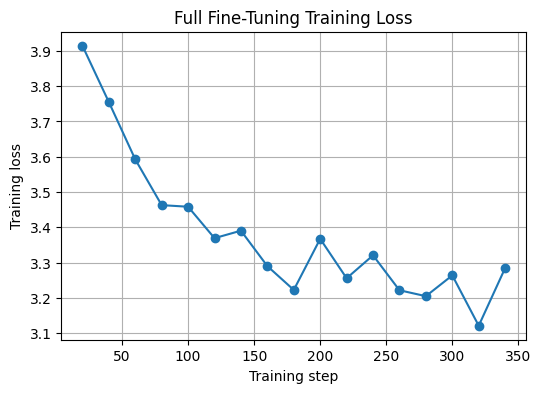

In [45]:
# Plot the training-loss curve or print a compact final training-loss record

print("Figure 1: Full Fine-Tuning Training Loss")
plt.figure(figsize=(6, 4))
plt.plot(loss_df["step"], loss_df["loss"], marker="o")
plt.xlabel("Training step")
plt.ylabel("Training loss")
plt.title("Full Fine-Tuning Training Loss")
plt.grid(True)
plt.show()

The full fine-tuning training-loss curve shows a clear overall decrease in training loss as training progressed, indicating that the model successfully learned the domain-specific language patterns from the UNDRIP parliamentary text. Although there were small fluctuations during training, the downward trend demonstrates stable learning and stronger adaptation to the target domain.

# Task 3 LoRA adaptation and comparison (25%)

Train a LoRA-adapted version of `distilgpt2` using the fixed LoRA configuration. Reload a fresh distilgpt2 base model before applying LoRA. Do not apply LoRA to the full fine-tuned model from Task 2.
Report the result in the master results table.


In [46]:
# Start LoRA from a fresh pretrained model, not from the full fine-tuned model.
lora_base_model = AutoModelForCausalLM.from_pretrained(BASE_MODEL)
lora_base_model.resize_token_embeddings(len(tokenizer))
lora_base_model.config.pad_token_id = tokenizer.pad_token_id

# Apply the fixed LoRA configuration
peft_config = LoraConfig(**LORA_CONFIG)
lora_model = get_peft_model(lora_base_model, peft_config)

# Show trainable LoRA parameters
lora_model.print_trainable_parameters()

# Set LoRA training arguments using fixed config
lora_training_args = TrainingArguments(**LORA_TRAINING_CONFIG)

# Train LoRA model
lora_trainer = Trainer(
    model=lora_model,
    args=lora_training_args,
    train_dataset=lm_train_dataset,
    eval_dataset=lm_val_dataset,
    data_collator=data_collator
)

start_time = time.time()
lora_train_result = lora_trainer.train()
end_time = time.time()
lora_training_time = (end_time - start_time) / 60

print(f"LoRA training time: {lora_training_time:.2f} minutes")

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2504: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


trainable params: 147,456 || all params: 82,060,032 || trainable%: 0.1797


Step,Training Loss
20,4.157879
40,4.169877
60,4.127413
80,3.997930
100,3.958599
120,3.875540
140,3.926178
160,3.837145
180,3.798718
200,3.950763


LoRA training time: 0.25 minutes


In [47]:
lora_trainable_params = sum(
    p.numel() for p in lora_model.parameters() if p.requires_grad
)
print(f"Trainable parameters in LoRA adaptation: {lora_trainable_params:,}")

Trainable parameters in LoRA adaptation: 147,456


In [48]:
lora_undrip_ppl = calculate_perplexity(
    lora_model,
    tokenizer,
    TEXT_FILES["validation"]
)

lora_economic_ppl = calculate_perplexity(
    lora_model,
    tokenizer,
    TEXT_FILES["test"]
)

print(f"LoRA-adapted PPL on UNDRIP validation: {lora_undrip_ppl:.2f}")
print(f"LoRA-adapted PPL on Economic test: {lora_economic_ppl:.2f}")

LoRA-adapted PPL on UNDRIP validation: 40.85
LoRA-adapted PPL on Economic test: 48.32


Figure 2: LoRA Training Loss


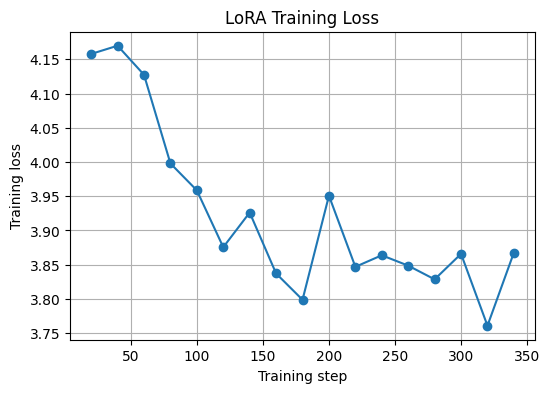

In [55]:
# LoRA training-loss records
lora_loss_logs = [
    log for log in lora_trainer.state.log_history
    if "loss" in log
]

lora_loss_df = pd.DataFrame(lora_loss_logs)
lora_loss_df
print("Figure 2: LoRA Training Loss")

plt.figure(figsize=(6, 4))

plt.plot(
    lora_loss_df["step"],
    lora_loss_df["loss"],
    marker="o"
)

plt.xlabel("Training step")
plt.ylabel("Training loss")
plt.title("LoRA Training Loss")
plt.grid(True)

plt.show()

The LoRA training-loss curve shows that the training loss gradually decreased as training progressed, indicating that the LoRA-adapted model was learning the domain-specific language patterns from the UNDRIP text. Although the loss fluctuations show that learning was less stable than full fine-tuning, the overall downward trend demonstrates successful adaptation with a much smaller number of trainable parameters.

## Generation comparison table

Use the fixed generation prompt exactly. Keep outputs short enough to be readable in the exported PDF.

| Prompt | Pretrained output | Full fine-tuned output | LoRA-adapted output | One-sentence comparison |
|---|---|---|---|---|
| `Economic self-determination for First Nations peoples requires` | Economic self-determination for First Nations peoples requires a strong commitment to the rights of all peoples. | Economic self-determination for First Nations peoples requires a determination for the rights of Indigenous peoples… | Economic self-determination for First Nations peoples requires a comprehensive and comprehensive international framework… | The pretrained output is short and generic, while the full fine-tuned and LoRA outputs use more Indigenous-rights and UN Declaration language, although both adapted models show repetition. |


In [53]:
def generate_text(model, prompt):
    """
    Generates text using a language model.
    """
    model.eval()

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    )

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    model.to(device)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=GENERATION_CONFIG["max_new_tokens"],
            do_sample=GENERATION_CONFIG["do_sample"],
            pad_token_id=tokenizer.eos_token_id
        )

    generated_text = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    # Remove excessive blank lines/spaces
    generated_text = re.sub(
        r"\n\s*\n+",
        "\n",
        generated_text
    ).strip()

    return generated_text


# Generate outputs
pretrained_output = generate_text(
    pretrained_model,
    GENERATION_PROMPT
)

full_output = generate_text(
    full_model,
    GENERATION_PROMPT
)

lora_output = generate_text(
    lora_model,
    GENERATION_PROMPT
)

print("Pretrained Output:\n")
print(pretrained_output)

print("\n" + "=" * 80 + "\n")

print("Full Fine-Tuned Output:\n")
print(full_output)

print("\n" + "=" * 80 + "\n")

print("LoRA-Adapted Output:\n")
print(lora_output)

Pretrained Output:

Economic self-determination for First Nations peoples requires a strong commitment to the rights of all peoples.


Full Fine-Tuned Output:

Economic self-determination for First Nations peoples requires a
determination for the rights of Indigenous peoples.
1.1 The UN Declaration on the Rights of Indigenous Peoples states:
1.2 The Declaration on the Rights of Indigenous Peoples states:
1.3 The Declaration on the Rights of Indigenous Peoples states:
1.4 The Declaration on the Rights of Indigenous Peoples states:
1.5 The Declaration on the Rights of Indigenous Peoples states


LoRA-Adapted Output:

Economic self-determination for First Nations peoples requires a comprehensive and comprehensive international framework for the development of the peoples of the world.
The UN Declaration of Principles on the Rights of Indigenous Peoples states that:
The rights of Indigenous Peoples are the fundamental rights of all peoples.
The rights of Indigenous Peoples are the fundamen

## Master results table

Complete this table across Tasks 1-3.

Training time depends on the runtime environment, so use it mainly for comparing your own full fine-tuning and LoRA runs under the same setup.

| Model state | Parameters updated during adaptation | Training time (minutes; compare within the same runtime) | PPL on UNDRIP validation | PPL on Economic test |
|---|---:|---:|---:|---:|
| Pretrained `distilgpt2` | 0  | 0 | 51.80 | 61.28 |
| Full fine-tuned `distilgpt2` | 81,912,576 | 0.52  | 27.23 | 37.13 |
| LoRA-adapted `distilgpt2` | 147,456 | 0.25 | 40.85 | 48.32 |


# Task 4 Interpretation and learning reflection (20%)

This task is about explanation and evidence of your individual learning.


## Task 4A Technical interpretation (15%)

Answer the following questions in at most **300 words** total. Your answers must refer to your own master results table and generation comparison table.

1. Using your reported perplexity values, what do your results show about adaptation to `undrip_val.txt` versus transfer to `economic_test.txt`?
2. Using your reported trainable-parameter count, training time, perplexity values, and generation comparison, what trade-off do you observe between full fine-tuning and LoRA?
3. Based on your own results, which method would you recommend under limited compute for a quick domain-adaptation baseline, and why?

Before writing, look at your master results table and generation comparison table. Your discussion should refer to your own reported values. For example: "Full fine-tuning reduced PPL on UNDRIP validation from X to Y, while LoRA reduced it to Z."

**Your response:**  

The results show that both full fine-tuning and LoRA adaptation improved performance compared to the pretrained baseline. Full fine-tuning reduced perplexity on the UNDRIP validation set from 51.80 to 27.23, while LoRA reduced it to 40.85. This indicates that full fine-tuning adapted more strongly to the parliamentary domain text. On the related economic_test.txt dataset, perplexity also improved from 61.28 to 37.13 for full fine-tuning and to 48.32 for LoRA, showing that both adapted models learned domain-related language patterns that transferred to the related Economic report.

The main trade-off between full fine-tuning and LoRA was performance versus efficiency. Full fine-tuning achieved the best perplexity values and produced more domain-specific generated text, but it updated 81,912,576 parameters and required more computational cost and training time. In comparison, LoRA updated only 147,456 trainable parameters while still improving perplexity noticeably over the pretrained model. However, because LoRA updates only a very small subset of parameters, its ability to adapt deeply to specialised language patterns is more limited, which explains why its transfer performance was weaker than full fine-tuning.

The generation outputs also showed repetition in both adapted models, particularly in the repeated “Declaration on the Rights of Indigenous Peoples” phrases. This likely happened because the training dataset was relatively small and highly repetitive in style, causing the models to overfit certain parliamentary patterns and repeatedly generate similar sequences.

Under limited compute, I would recommend LoRA for a quick domain-adaptation baseline because it achieved meaningful improvement while updating far fewer parameters and using lower computational cost.

## Task 4B Learning reflection (5%)

Answer the following question in at most **150 words**.

Over the 11 weeks of this unit, what is one intuition about deep learning that has changed, become clearer, or become more nuanced for you?

Your answer should include:

- one earlier intuition, assumption, or misconception;
- the concept, activity, result, lecture, practical, or example that changed or refined it;
- what you now understand differently;
- how this would affect the way you approach a future deep learning problem.

**Your response:**

Earlier in the unit, I assumed that effective deep learning models usually required training large networks from scratch and updating all parameters and large computational resources. This assignment changed that understanding by showing how pretrained language models can be adapted efficiently to a specialised domain using fine-tuning and LoRA.

The comparison between full fine-tuning and LoRA helped me understand the trade-off between performance and efficiency more clearly. Although full fine-tuning achieved lower perplexity, LoRA was still able to improve performance significantly while updating only a very small number of parameters. Seeing this difference directly in my own results made the idea of parameter-efficient adaptation much clearer.

This has changed how I would approach future deep learning problems. Instead of immediately considering large-scale training, I would first explore pretrained models and efficient adaptation methods depending on the available compute and project requirements.
